In [7]:
from astropy import units as u
from astropy.constants import G, c
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import spacehub_calc
from spacehub_calc import TwoBodyOrbit, mag, Theorize
import matplotlib.animation as animation
from IPython.display import HTML
from orbits import distance, get_com, calc_angle
import orbits

### Equations and IC calculations

$M_1 = M_2 = M_3 = 10 M_{\odot}$

$R_1 = R_2 = R_3 = \frac{2GM}{c^2} = \frac{20GM_{\odot}}{c^2}$

$a_0 = 10^{-2}AU$

$r_{start} = 20AU$

$cos(\gamma) = 1$ (co-planar)

$v_{orb}^2 = GM_{tot}(\frac{2}{r_{12}} - \frac{1}{a_0}) \leftarrow$ (vis-visa, $t=0$)

$v = \frac{v_{\infty}}{v_{orb}\sqrt{3}} = 0.01$

$\rightarrow v_{\inf} = 0.01v_{orb}\sqrt{3} = 0.01\sqrt{3GM_{tot}(\frac{2}{r_{12}} - \frac{1}{a_0})}$

$b = b_{\inf}/b_{c} = \frac{b_{inf}v}{a_0}$

$b\in[-4, 4]$

$b_{\inf} = \frac{ba_0}{v}$

$f_{20} \in [0, 2\pi]$

$r_{start} = 20\times a_0$



In [8]:
#Initial conditions/configs
m1, m2, m3 = 10*u.Msun, 10*u.Msun, 10*u.Msun
Mtot = 30 * u.Msun
a = 1e-4 * u.AU

In [9]:
vc = np.sqrt( G * (m1 * m2 * (m1+m2+m3) / (a * m3 * (m1 + m2))) ) # Hut & Bachall 1983
(0.01 * vc).to(u.km / u.s)

<Quantity 115.35561543 km / s>

In [10]:
#Hut & Bahcall suggested bmax
C = 4
D = 0.6
a*((C/0.01) + D)

<Quantity 0.04006 AU>

In [11]:
def b_inf(b, a0, v):
    return  b * a0 / (v)

b = np.linspace(-4, 4, 10)
[b_inf(bi, a, 0.01) for bi in b]

[<Quantity -0.04 AU>,
 <Quantity -0.03111111 AU>,
 <Quantity -0.02222222 AU>,
 <Quantity -0.01333333 AU>,
 <Quantity -0.00444444 AU>,
 <Quantity 0.00444444 AU>,
 <Quantity 0.01333333 AU>,
 <Quantity 0.02222222 AU>,
 <Quantity 0.03111111 AU>,
 <Quantity 0.04 AU>]

In [12]:
R_s = 20 * G * u.Msun / c**2

R_s.to(u.Rsun)

<Quantity 4.24500514e-05 solRad>

In [13]:
a0 = a
e0 = 0
m1, m2 = 10, 10
m1 = m1 * u.Msun
m2 = m2 * u.Msun
beta = (64/5) * G**3 * m1 * m2 * (m1+m2) * c**(-5) #Idk if the c^-5 is supposed to be here, but it fixes the units. G and c are not hard to write. stop using G=C=1
f = Theorize.enhancement_factor(e0)

T = a0**4 / (4*beta*f)
T.to(u.yr)

<Quantity 0.01605707 yr>

### Data Processing & Figures

In [14]:
ptc_file = "simulation_results/topology/fig4_ptc.dat"

In [15]:
def load_mt_data(fname):
    
    datain = pd.read_csv(fname, index_col=False)
    data = datain[datain["id"]>=0]
    ics_df = datain[datain["id"]==-2]
    
    # Rename columns for ics_df
    ics_df.columns = ['time', 'id', 'b', 'azi', 'incl', 'ec', 'ci', 'cj', 'n']
    ics_df = ics_df.reset_index()
    #print(data)
    dic = {name: data[name].to_numpy() for name in data.columns}
    particle_num = len(np.unique(dic['id']))
    print(particle_num)

    splited_dic = {}
    splited_dic['time'] = dic['time'][dic['id'] == 0]
    for i in range(particle_num):
        for key in dic.keys():
            if key != 'time' and key != 'id':
                splited_dic[key + str(i)] = dic[key][dic['id'] == i]

    orbits.get_norm(particle_num, splited_dic)

    return ics_df, splited_dic

indf, data = load_mt_data(ptc_file)
indf


3


,index,time,id,b,azi,incl,ec,ci,cj,n
0,3,0.000702,-2,-0.040000,0.000000,0.0,0.0,-1.0,-1.0,0.0
1,7,0.000702,-2,-0.040000,0.031574,0.0,0.0,-1.0,-1.0,0.0
2,11,0.000702,-2,-0.040000,0.063148,0.0,0.0,-1.0,-1.0,0.0
3,15,0.000702,-2,-0.040000,0.094721,0.0,0.0,-1.0,-1.0,0.0
4,19,0.000702,-2,-0.040000,0.126295,0.0,0.0,-1.0,-1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
39995,159983,0.000702,-2,-0.020302,6.156890,0.0,0.0,-1.0,-1.0,0.0
39996,159987,0.000295,-2,-0.020302,6.188460,0.0,1.0,1.0,2.0,0.0
39997,159991,0.000111,-2,-0.020302,6.220040,0.0,2.0,0.0,2.0,0.0
39998,159995,0.000358,-2,-0.020302,6.251610,0.0,2.0,1.0,2.0,0.0


In [16]:
npoints = len(data["time"])
data["ecc01"] = mag(orbits.get_ecc(data, 0, 1))
data["ecc02"] = mag(orbits.get_ecc(data, 0, 2))
data["ecc12"] = mag(orbits.get_ecc(data, 1, 2))
data["rx01"], data["ry01"], data["rz01"] = distance(data, 'p', 0, 1)
data["rx02"], data["ry02"], data["rz02"] = distance(data, 'p', 0, 2)
data["rx12"], data["ry12"], data["rz12"] = distance(data, 'p', 1, 2)

In [17]:
#outcomes = ["Coll[01]", "Coll[02]", "Coll[12]", "GW[ij]", "BS[01]", "BS[02]", "BS[12]", "VLint", "Failed"] #GW-Coll distinction not yet implemented
result_df = pd.DataFrame(columns=["b", "azi", "incl", "endstate", "ionized", "BC[ijk]", "Coll[ij]", "VLInt", "failed", "rx01", "ry01", "rz01", "rx02", "ry02", "rz02", "rx12", "ry12", "rz12"])
#BC -> bound component
rows = []
for i in range(0, npoints):
    row = {}
    
    
    #print(f"{data[""]}")
    row["b"] = indf.at[i, "b"]
    row["azi"] = indf.at[i, "azi"]
    row["incl"] = indf.at[i, "incl"]
    ec = indf.at[i, "ec"]
    if data["time"][i] < 0:
        row["failed"] = 1
        continue
    else:
        row["failed"] = 0

    
    ci = indf.at[i, "ci"]
    cj = indf.at[i, "cj"]
    if (ci < 0):

        Collij = {}
    else:
        Collij = {ci, cj}

    row["ionized"] = 1 if data["ecc01"][i]  >= 1 else 0
    row["VLint"] = False
        
    e_ij = np.array([data["ecc01"][i], data["ecc02"][i], data["ecc12"][i]])
    bound = np.where((e_ij > 0) & (e_ij < 1))[0]
    if len(bound) == 0:
        BCijk = {}
    elif len(bound) > 1:
        BCijk = {1, 2, 3}
        row["VLint"] = True
    elif bound[0] == 0:
        BCijk = {0, 1}
    elif bound[0] == 1:
        BCijk = {0, 2}
    elif bound[0] == 2:
        BCijk = {1, 2}
    
    
    #----------Precedence: Failed, Collision, (to do GW), BS[ij]/VLInt, 
    if row["failed"] == 1:
        row["endstate"] = "failed"
    
    elif row["VLint"]:
        row["endstate"] = "VLint"

    elif (ec == 1) and (len(Collij) == 2):
        row["endstate"] = "Coll"

    elif (ec == 2) and (len(Collij) == 2):
        row["endstate"] = "GW"

    elif len(BCijk) == 2:
        row["endstate"] = "BS[" + str(BCijk)[1:-1].replace(", ","") + "]"

    elif len(BCijk) <= 1:
        row["endstate"] = "?"
    #outcomes = ["Coll[01]", "Coll[02]", "Coll[12]", "GW[ij]", "BS[01]", "BS[02]", "BS[12]", "VLint", "Failed"]
    #add distances in case I want to plot in cartesian
    row["rx01"], row["ry01"], row["rz01"] = data["rx01"][i], data["ry01"][i], data["rz01"][i]
    row["rx02"], row["ry02"], row["rz02"] = data["rx02"][i], data["ry02"][i], data["rz02"][i]
    row["rx12"], row["ry12"], row["rz12"] = data["rx12"][i], data["ry12"][i], data["rz12"][i]

    rows.append(row)

result_df = pd.DataFrame(rows)
        
result_df
    

,b,azi,incl,failed,ionized,VLint,endstate,rx01,ry01,rz01,rx02,ry02,rz02,rx12,ry12,rz12
0,-0.040000,0.000000,0.0,0,0,False,BS[01],0.0,-0.000075,0.000066,0.0,-3.919760e-02,7.276780e-03,0.0,-3.912300e-02,7.210440e-03
1,-0.040000,0.031574,0.0,0,0,False,BS[01],0.0,-0.000074,0.000067,0.0,-3.919750e-02,7.277050e-03,0.0,-3.912320e-02,7.210310e-03
2,-0.040000,0.063148,0.0,0,0,False,BS[01],0.0,-0.000074,0.000067,0.0,-3.919740e-02,7.277360e-03,0.0,-3.912360e-02,7.210170e-03
3,-0.040000,0.094721,0.0,0,0,False,BS[01],0.0,-0.000073,0.000068,0.0,-3.919720e-02,7.277690e-03,0.0,-3.912380e-02,7.210000e-03
4,-0.040000,0.126295,0.0,0,0,False,BS[01],0.0,-0.000073,0.000068,0.0,-3.919710e-02,7.278050e-03,0.0,-3.912420e-02,7.209800e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-0.020302,6.156890,0.0,0,0,False,BS[01],0.0,-0.000029,-0.000134,0.0,-3.517290e-03,-1.271696e-02,0.0,-3.488160e-03,-1.258297e-02
39996,-0.020302,6.188460,0.0,0,1,False,Coll,0.0,0.000198,-0.000124,0.0,1.981127e-04,-1.240967e-04,0.0,-2.663000e-07,1.358000e-07
39997,-0.020302,6.220040,0.0,0,1,False,GW,0.0,0.000209,0.000312,0.0,-4.967000e-07,1.140000e-07,0.0,-2.099587e-04,-3.116630e-04
39998,-0.020302,6.251610,0.0,0,1,False,GW,0.0,-0.000294,-0.000055,0.0,-2.944957e-04,-5.503110e-05,0.0,-3.796000e-07,-2.424000e-07


(-0.04, 0.04)

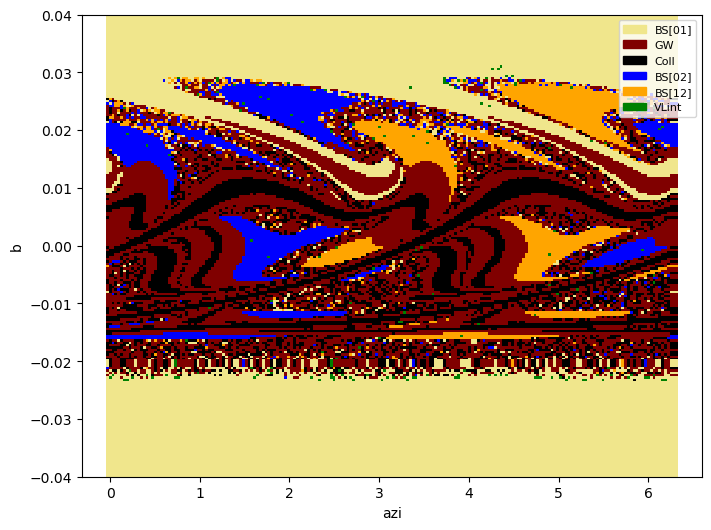

In [20]:
fig, ax = plt.subplots(figsize = (8,6))
palette = {
    'VLint': 'green',
    'Coll': 'black',
    'BS[01]': 'khaki',
    'BS[02]': 'blue',
    'BS[12]': 'orange',
    'GW':    'maroon',
    '?': 'white'
}

sns.scatterplot(result_df, x='azi', y='b', hue='endstate', palette=palette, marker = ",", linewidth=0, ax=ax)
handles, labels = ax.get_legend_handles_labels()
patches = []
for handle, label in zip(handles, labels):
    patches.append(mpatches.Patch(color=handle.get_color(), label = label))

legend = ax.legend(handles=patches, fontsize=8)
plt.ylim(-0.04,0.04)




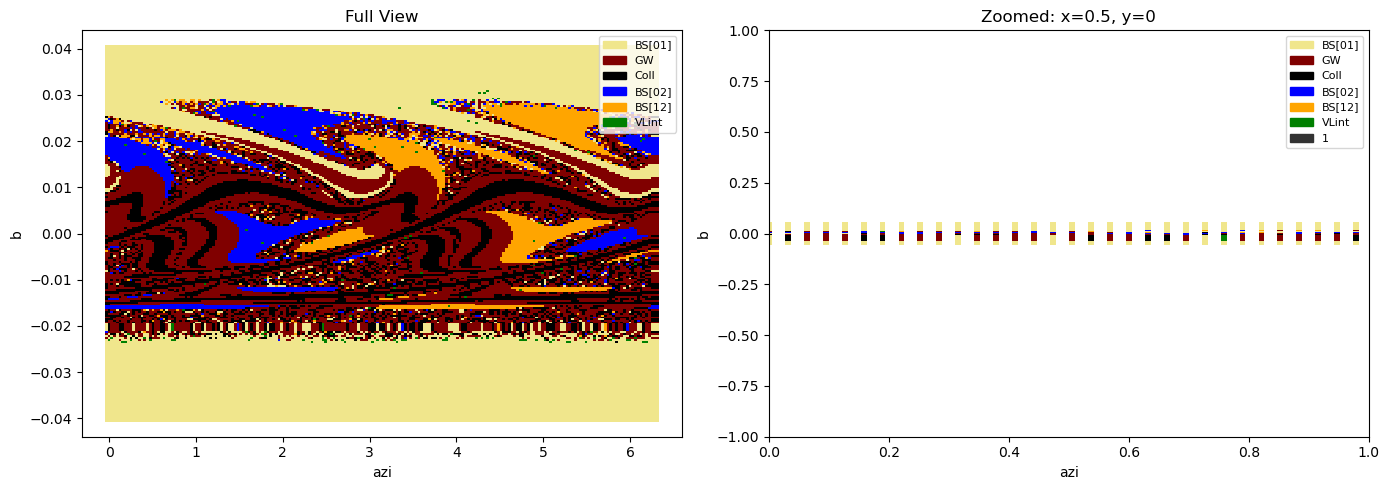

In [19]:


remove_failed_sims = ~result_df["endstate"].isin(["failed", "?"])
masked_results = result_df[remove_failed_sims]
palette = {
    'VLint': 'green',
    'Coll': 'black',
    'BS[01]': 'khaki',
    'BS[02]': 'blue',
    'BS[12]': 'orange',
    'GW':    'maroon',
    '?': 'white'
}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel - original plot
sns.scatterplot(result_df, x='azi', y='b', hue='endstate', palette=palette, ax=ax1, marker=",", linewidth=0)

handles, labels = ax1.get_legend_handles_labels()
patches = []
for handle, label in zip(handles, labels):
    patches.append(mpatches.Patch(color=handle.get_color(), label = label))

legend1 = ax1.legend(handles=patches, fontsize=8)


ax1.set_title('Full View')

# Right panel - zoomed in on x=0.5, y=0
sns.scatterplot(result_df, x='azi', y='b', hue='endstate', palette=palette, marker = ",", size=1, linewidth = 0, ax=ax2)
ax2.set_xlim(0, 1)  # Zoomed around x=0.5
ax2.set_ylim(-1, 1)  # Zoomed around y=0
ax2.legend(loc='upper right')
ax2.set_title('Zoomed: x=0.5, y=0')

handles, labels = ax2.get_legend_handles_labels()
patches = []
for handle, label in zip(handles, labels):
    patches.append(mpatches.Patch(color=handle.get_color(), label = label))

legend2 = ax2.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.show()